# 1 · plot — Top7 contact map

Draws the dataset written by [`1_make_top7_heatmap_data.ipynb`](1_make_top7_heatmap_data.ipynb).
No GPU, no model: everything comes from the stored prediction.

Two figures, because the two are read differently — a single mirrored square when the reader
should see one object, and two panels when they should compare like with like:

* `top7_heatmap_mirrored` — prediction above the diagonal, observed contacts below.
* `top7_heatmap_side_by_side` — observed on the left, predicted on the right.

Both are masked to the pairs the metric scores: a blank region means *not scorable* (an
unresolved residue, or separation < 6), not *no contact*.

In [1]:
# Run from anywhere: figlib lives next to this notebook.
import sys
from pathlib import Path

HERE = Path.cwd() if (Path.cwd() / "figlib.py").exists() else Path("experiments/exp250_evals_exploration_notebook/figures")
sys.path.insert(0, str(HERE.resolve()))
import figlib

In [2]:
DATASET = "1_top7_heatmap"
DPI = 300                # PNG resolution; the PDF beside it is vector
metadata = figlib.describe(DATASET)

dataset      1_top7_heatmap
made by      1_make_top7_heatmap_data.ipynb
generated    2026-08-21T16:31:39+00:00
machine      1xH100 node · python 3.12.14 · NVIDIA H100 80GB HBM3 (79.2 GiB, cc 9.0)
checkout     2f30f1bb15de on exp250/evals-exploration-notebook  ** UNCOMMITTED CHANGES **
packages     marinfold 0.1.0, torch 2.11.0+cu129, transformers 4.57.6, vllm 0.20.2+cu129, numpy 2.3.5, pandas 3.0.5, matplotlib 3.11.1

parameters
   protein                  denovo_pdb__1qys_A
   model                    contacts-v1-exp232-m2-p06-1.5B
   n_rollouts               100
   temperature              1.0
   top_p                    0.95
   top_k                    -1
   backend                  auto
   dtype                    auto
   gpu_memory_utilization   0.85

model
   nickname                 contacts-v1-exp232-m2-p06-1.5B
   rope_theta               500000
   vocab_size               2845
   weights                  5.48 GiB

inputs
   17336c8bcfdc        114,366 B  /home/ubuntu/MarinFol

In [3]:
import json
import os

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from matplotlib.colors import LinearSegmentedColormap, to_rgb

figlib.figure_style(DPI)
directory = figlib.require(DATASET, "score.npy", "votes.npy", "ground_truth.json",
                           "ca_coords.npy", "structure.cif", "residue_numbers.npy")
score = np.load(directory / "score.npy")        # votes + tie-break; what the metric ranks
votes = np.load(directory / "votes.npy")        # the rollout count itself
n_rollouts = metadata["parameters"]["n_rollouts"]
truth_record = json.loads((directory / "ground_truth.json").read_text())

length = truth_record["L"]
truth = figlib.true_matrix(length, truth_record["contacts"])
resolved = np.zeros(length, bool)
resolved[np.asarray(truth_record["resolved"])] = True
scorable = np.outer(resolved, resolved)
scorable &= np.abs(np.subtract.outer(np.arange(length), np.arange(length))) >= figlib.MIN_SEPARATION
# With origin="lower", element [i, j] is drawn at x=j, y=i — so the VISUALLY upper-left
# triangle is i > j (np.tril), NOT np.triu. Getting this the wrong way round mirrors the
# figure while leaving the annotations reading correctly, which is as invisible as it sounds.
visually_upper = np.tril(np.ones((length, length), bool), k=-1)
# The colour is the fraction of rollouts that asserted the pair — an absolute 0-1 scale, not one
# normalised to this protein's strongest pair, so two proteins' maps are comparable and a washed
# out map means the model was never confident rather than that it had a weak best guess. The
# tie-break term is deliberately excluded: it orders tied pairs for the metric and is not
# evidence about a contact.
confidence = np.where(scorable, votes / n_rollouts, np.nan)
print(f"strongest pair: {np.nanmax(confidence):.0%} of {n_rollouts} rollouts · "
      f"{int(np.nansum(np.triu(confidence, k=1) > 0))} pairs got at least one vote")

# One colormap for "position along the chain", used by the ribbon and by the strips along the
# contact map's axes. Same colour = same residue in both figures, which is the whole point of
# drawing them together.
CHAIN_CMAP = "viridis"


def chain_strips(axis, length, cmap=CHAIN_CMAP, width=0.028, pad=0.012):
    """Paint an N-to-C colour bar along the bottom and left edges of a contact map.

    The ribbon figure colours the fold by the same scale, so a feature in the map can be found on
    the structure by matching colour instead of counting residues.
    """
    gradient = np.linspace(0, 1, length)[None, :]
    bottom = axis.inset_axes([0, -width - pad, 1, width])
    bottom.imshow(gradient, aspect="auto", cmap=cmap)
    left = axis.inset_axes([-width - pad, 0, width, 1])
    left.imshow(gradient.T, aspect="auto", cmap=cmap, origin="lower")
    for strip in (bottom, left):
        strip.set_xticks([]); strip.set_yticks([])
        for spine in strip.spines.values():
            spine.set_visible(False)
    return bottom, left


HEAT = LinearSegmentedColormap.from_list("votes", ["#FFFFFF", "#F4C36B", "#C44E52", "#3B0A0C"])
OBSERVED = LinearSegmentedColormap.from_list("gt", ["#2F2F2F", "#2F2F2F"])
PDB_ID = truth_record["stem"].split("_")[0].upper()
print(f"{truth_record['stem']}  ({PDB_ID})  L={length}  "
      f"{int(truth.sum() // 2)} observed contacts")

strongest pair: 97% of 100 rollouts · 539 pairs got at least one vote
1qys_A  (1QYS)  L=92  76 observed contacts


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/experiments/exp250_evals_exploration_notebook/figures/output/top7_heatmap_mirrored.{png,pdf,svg} (300 dpi)


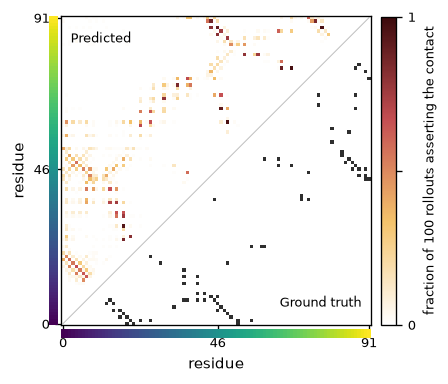

In [4]:
# --- mirrored square ---------------------------------------------------------------------------
figure, axis = plt.subplots(figsize=(3.6, 3.6))
image = axis.imshow(np.where(visually_upper, confidence, np.nan), cmap=HEAT, origin="lower",
                    interpolation="none", vmin=0, vmax=1)
axis.imshow(np.where(~visually_upper & truth & scorable, 1.0, np.nan), cmap=OBSERVED, origin="lower",
            interpolation="none", vmin=0, vmax=1)
axis.plot([0, length - 1], [0, length - 1], color="0.75", lw=0.6)
axis.set(xlabel="residue", ylabel="residue")
axis.set_xticks([0, length // 2, length - 1])
axis.set_yticks([0, length // 2, length - 1])
for spine in ("top", "right"):
    axis.spines[spine].set_visible(True)
bar = figure.colorbar(image, ax=axis, fraction=0.046, pad=0.03, ticks=[0, 0.5, 1.0])
bar.set_label(f"fraction of {n_rollouts} rollouts asserting the contact", fontsize=8)
bar.ax.set_yticklabels(["0", "", "1"])
axis.text(0.03, 0.95, "Predicted", transform=axis.transAxes, ha="left", va="top", fontsize=8)
axis.text(0.97, 0.05, "Ground truth", transform=axis.transAxes, ha="right",
          va="bottom", fontsize=8)
chain_strips(axis, length)
figlib.save_figure(figure, "top7_heatmap_mirrored", DPI)
plt.show()

wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/experiments/exp250_evals_exploration_notebook/figures/output/top7_heatmap_side_by_side.{png,pdf,svg} (300 dpi)


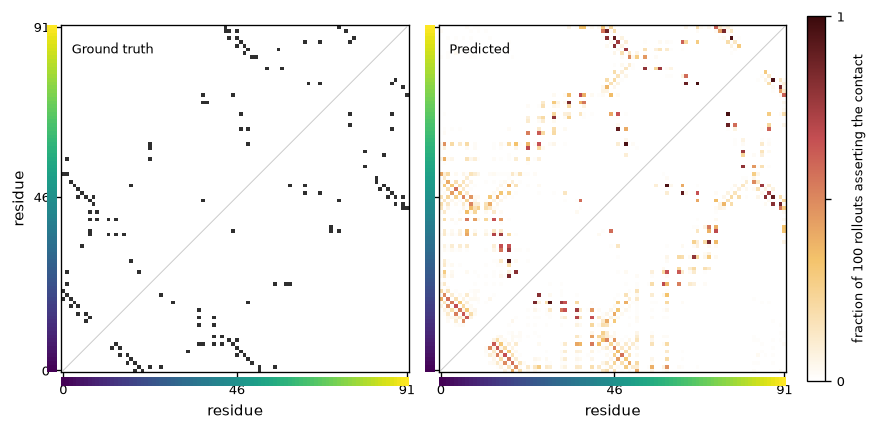

In [5]:
# --- side by side ------------------------------------------------------------------------------
# constrained_layout with the colorbar attached to BOTH axes keeps the panels the same size;
# hanging it off the right panel alone silently shrinks that one.
figure, axes = plt.subplots(1, 2, figsize=(7.2, 3.5), sharey=True, layout="constrained")
axes[0].imshow(np.where(truth & scorable, 1.0, np.nan), cmap=OBSERVED, origin="lower",
               interpolation="none", vmin=0, vmax=1)
image = axes[1].imshow(confidence, cmap=HEAT, origin="lower", interpolation="none", vmin=0, vmax=1)
axes[0].set(xlabel="residue", ylabel="residue")
axes[1].set(xlabel="residue")
for axis, note in zip(axes, ("Ground truth", "Predicted")):
    axis.plot([0, length - 1], [0, length - 1], color="0.8", lw=0.6)
    axis.set_xticks([0, length // 2, length - 1])
    axis.set_yticks([0, length // 2, length - 1])
    axis.text(0.03, 0.95, note, transform=axis.transAxes, ha="left", va="top", fontsize=8)
    for spine in ("top", "right"):
        axis.spines[spine].set_visible(True)
bar = figure.colorbar(image, ax=list(axes), fraction=0.046, pad=0.02, ticks=[0, 0.5, 1.0])
bar.set_label(f"fraction of {n_rollouts} rollouts asserting the contact", fontsize=8)
bar.ax.set_yticklabels(["0", "", "1"])
for axis in axes:
    chain_strips(axis, length)
figlib.save_figure(figure, "top7_heatmap_side_by_side", DPI)
plt.show()

In [6]:
# --- the fold, coloured N to C: shared colour assignment ----------------------------------------
# Both renderers below colour residue i with CHAIN_CMAP(i / (L-1)) — the same scale painted along
# the contact map's axes — so a contact in the map can be found on the structure by matching
# colour instead of counting residues. The deposited chain is numbered 3..94 while the map is
# indexed 0..91, so the author residue numbers stored by the make notebook are what gets coloured.
from matplotlib.colors import to_hex

structure_cif = (directory / "structure.cif").read_text()
residue_numbers = np.load(directory / "residue_numbers.npy")
chain_id = metadata["structure"]["chain"]
resolved_indices = np.flatnonzero(residue_numbers >= 0)

RESIDUE_COLOR = {                       # author residue number -> hex colour
    int(residue_numbers[i]): to_hex(plt.get_cmap(CHAIN_CMAP)(i / max(1, length - 1)))
    for i in resolved_indices
}
print(f"{PDB_ID} chain {chain_id}: {len(RESIDUE_COLOR)} residues coloured, "
      f"author numbering {residue_numbers[resolved_indices].min()}–"
      f"{residue_numbers[resolved_indices].max()} for sequence indices "
      f"{resolved_indices.min()}–{resolved_indices.max()}")

1QYS chain A: 92 residues coloured, author numbering 3–94 for sequence indices 0–91


In [7]:
# --- interactive cartoon (py3Dmol) --------------------------------------------------------------
# Drag to rotate, scroll to zoom. This is the one to look at while working; the ray-traced cell
# below is the one to put in a document. Needs `pip install py3Dmol` (pure JS, no GPU).
VIEW_WIDTH, VIEW_HEIGHT = 620, 520
SPIN = False   # set True to have it rotate on its own

try:
    import py3Dmol
except ImportError:
    print("py3Dmol is not installed — `pip install py3Dmol` and re-run this cell")
else:
    view = py3Dmol.view(width=VIEW_WIDTH, height=VIEW_HEIGHT)
    view.addModel(structure_cif, "cif")
    view.setStyle({}, {"cartoon": {"color": "#DDDDDD"}})
    for residue_number, color in RESIDUE_COLOR.items():
        view.setStyle({"chain": chain_id, "resi": str(residue_number)},
                      {"cartoon": {"color": color, "arrows": True}})
    first, last = min(RESIDUE_COLOR), max(RESIDUE_COLOR)
    for residue_number, label in ((first, "N"), (last, "C")):
        view.addLabel(label, {"fontSize": 15, "fontColor": "black", "backgroundOpacity": 0.55,
                              "backgroundColor": "white"},
                      {"chain": chain_id, "resi": str(residue_number), "atom": "CA"})
    view.setBackgroundColor("0xffffff")
    view.zoomTo({"chain": chain_id})
    view.spin(SPIN)
    view.show()

py3Dmol is not installed — `pip install py3Dmol` and re-run this cell


wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/experiments/exp250_evals_exploration_notebook/figures/output/top7_map_ground_truth.{png,pdf,svg} (300 dpi)


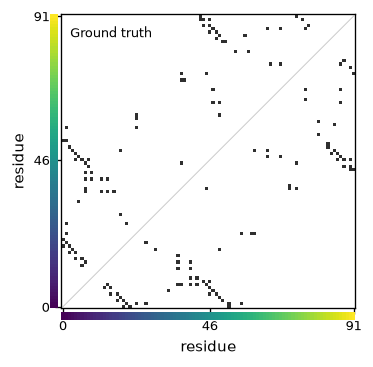

wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/experiments/exp250_evals_exploration_notebook/figures/output/top7_map_predicted.{png,pdf,svg} (300 dpi)


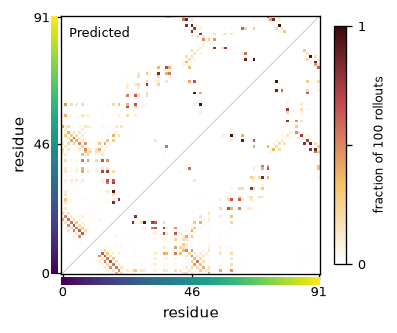

In [8]:
# --- the same two maps as separate panels -------------------------------------------------------
# A manuscript figure letters panels individually, so ground truth and prediction are also written
# as standalone squares. Same masking, same colour scale, same N-to-C strips as the pair above.
for name, data, cmap, note, with_bar in (
        ("top7_map_ground_truth", np.where(truth & scorable, 1.0, np.nan), OBSERVED,
         "Ground truth", False),
        ("top7_map_predicted", confidence, HEAT, "Predicted", True)):
    figure, axis = plt.subplots(figsize=(3.2, 2.95), layout="constrained")
    image = axis.imshow(data, cmap=cmap, origin="lower", interpolation="none", vmin=0, vmax=1)
    axis.plot([0, length - 1], [0, length - 1], color="0.8", lw=0.6)
    axis.set(xlabel="residue", ylabel="residue")
    axis.set_xticks([0, length // 2, length - 1])
    axis.set_yticks([0, length // 2, length - 1])
    axis.text(0.03, 0.96, note, transform=axis.transAxes, ha="left", va="top", fontsize=8)
    for spine in ("top", "right"):
        axis.spines[spine].set_visible(True)
    # Both panels reserve the colourbar's footprint even though only the prediction needs one —
    # otherwise the ground-truth map is drawn larger than the prediction it is compared against,
    # which reads as significance and is only layout.
    bar = figure.colorbar(image, ax=axis, fraction=0.046, pad=0.03, ticks=[0, 0.5, 1.0])
    if with_bar:
        bar.set_label(f"fraction of {n_rollouts} rollouts", fontsize=7)
        bar.ax.set_yticklabels(["0", "", "1"])
    else:
        bar.ax.set_visible(False)
    chain_strips(axis, length)
    figlib.save_figure(figure, name, DPI, tight=False)
    plt.show()

wrote /home/bizon/git/MarinFold/.claude/worktrees/evals-exploration-notebook-cba1c7/experiments/exp250_evals_exploration_notebook/figures/output/document_format.{png,pdf,svg} (300 dpi)


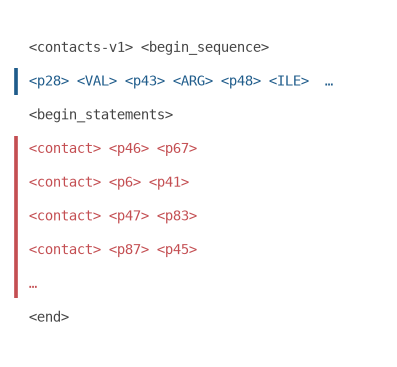

190 framing+sequence tokens, 76 contact statements, 420 tokens total


In [9]:
# --- the document format ------------------------------------------------------------------------
# Figure 1a. Drawn from the real document the make notebook stored, not a mock-up: these are the
# actual tokens, in the actual order, with the actual section boundaries the model was trained on.
# Both sections are elided in the middle — the panel is about the format, not the 92 residues.
DOC_SEQUENCE_TOKENS = 6   # sequence tokens shown (3 <position> <amino acid> pairs)
DOC_STATEMENTS = 4        # contact statements shown before the ellipsis

document_text = (directory / "document.txt").read_text()
head, _, tail = document_text.partition("<begin_statements>")
tokens = head.split()
statements = ["<contact>" + part.rstrip() for part in tail.split("<contact>")[1:]]

# tokens[:2] is the framing; the sequence section starts at the first position token.
lines = [
    (" ".join(tokens[:2]), "frame"),
    (" ".join(tokens[2:2 + DOC_SEQUENCE_TOKENS]) + "  …", "sequence"),
    ("<begin_statements>", "frame"),
]
lines += [(" ".join(s.split()[:3]), "statements") for s in statements[:DOC_STATEMENTS]]
lines += [("…", "statements"), ("<end>", "frame")]

SECTION_COLOR = {"frame": "#444444", "sequence": "#1F5C8B", "statements": "#C44E52"}
TEXT_X = 0.045   # the coloured section rules sit just left of this

FIG1_PANEL = (3.2, 2.95)   # every figure-1 panel is drawn at this exact size
figure, axis = plt.subplots(figsize=FIG1_PANEL, layout="constrained")
axis.set_axis_off()
axis.set(xlim=(0, 1), ylim=(-0.6, len(lines) + 0.6))
for row, (text, section) in enumerate(lines):
    axis.text(TEXT_X, len(lines) - row - 0.5, text, family="monospace", fontsize=8.5,
              va="center", color=SECTION_COLOR[section])

# A coloured rule beside the rows each section spans. The sections are named in the caption, not
# on the panel: annotation text competed with the tokens, which are the subject here.
for section in ("sequence", "statements"):
    rows = [row for row, (_, kind) in enumerate(lines) if kind == section]
    top, bottom = len(lines) - min(rows), len(lines) - max(rows) - 1
    axis.plot([0.012, 0.012], [bottom + 0.1, top - 0.1], color=SECTION_COLOR[section], lw=2.2,
              solid_capstyle="butt")

figlib.save_figure(figure, "document_format", DPI, tight=False)
plt.show()
print(f"{len(tokens)} framing+sequence tokens, {len(statements)} contact statements, "
      f"{len(document_text.split())} tokens total")

In [10]:
# --- ray-traced cartoons (PyMOL), one per viewing angle -------------------------------------------
# The publication version: real cartoon geometry — helices as ribbons, strands as arrows — which
# matplotlib cannot draw and py3Dmol cannot save headlessly. PyMOL is an external binary rather
# than a Python dependency, so this cell reports how to get it instead of failing the notebook if
# it is absent; every other figure here is unaffected.
#
# Every view starts from PyMOL's `orient` (deterministic for a given structure) and then turns
# from there, so the set is reproducible and the names mean something.
import shutil
import subprocess
import tempfile

PYMOL = os.environ.get("PYMOL") or shutil.which("pymol") or str(Path.home() / "pymolenv/bin/pymol")
RAY_WIDTH, RAY_HEIGHT = 1600, 1400
VIEWS = {
    "front": [],
    "back": ["turn y, 180"],
    "left": ["turn y, -90"],
    "right": ["turn y, 90"],
    "top": ["turn x, 90"],
    "tilted": ["turn y, 35", "turn x, 25"],
}

if not Path(PYMOL).exists() and shutil.which(PYMOL) is None:
    print(f"PyMOL not found at {PYMOL!r}. Install it with:")
    print("    micromamba create -y -p ~/pymolenv -c conda-forge pymol-open-source")
    print("or point the PYMOL environment variable at an existing binary, then re-run this cell.")
else:
    figlib.OUTPUT.mkdir(parents=True, exist_ok=True)
    scratch = Path(tempfile.mkdtemp(prefix="top7-cartoon-"))
    colour_commands = []
    for number, colour in sorted(RESIDUE_COLOR.items()):
        red, green, blue = to_rgb(colour)
        colour_commands.append(f"set_color c{number}, [{red:.4f}, {green:.4f}, {blue:.4f}]")
        colour_commands.append(f"color c{number}, chain {chain_id} and resi {number}")

    # One PyMOL process for all views: load and colour once, then ray trace each angle.
    script = [
        f"load {directory / 'structure.cif'}, protein",
        "hide everything",
        f"show cartoon, chain {chain_id} and polymer",
        "set cartoon_fancy_helices, 1",
        "set cartoon_smooth_loops, 1",
        "set cartoon_flat_sheets, 1",
        "set ray_shadows, 0",
        "set specular, 0.15",
        "set ambient, 0.28",
        "set direct, 0.55",
        "set antialias, 2",
        "set ray_opaque_background, 1",
        "bg_color white",
        *colour_commands,
    ]
    for view_name, turns in VIEWS.items():
        script += ["orient", *turns, f"zoom chain {chain_id}, 1",
                   f"ray {RAY_WIDTH}, {RAY_HEIGHT}",
                   f"png {scratch / view_name}.png, dpi={DPI}"]

    script_path = scratch / "render.pml"
    script_path.write_text(os.linesep.join(script))
    result = subprocess.run([PYMOL, "-cq", str(script_path)], capture_output=True, text=True)
    missing = [name for name in VIEWS if not (scratch / f"{name}.png").exists()]
    if result.returncode != 0 or missing:
        print(result.stdout[-2000:])
        print(result.stderr[-2000:])
        raise RuntimeError(f"PyMOL did not render {missing or 'anything'}; its output is above")


def compose_cartoon(image_path, name):
    """Crop a ray-traced render to its own ink and add the N-to-C key beneath it.

    PyMOL leaves a wide white margin and cannot draw a colour key, and a panel that says
    "coloured N to C" only in its caption is a panel that loses that when it is reused.
    """
    rendered = plt.imread(image_path)
    ink = np.any(rendered[..., :3] < 0.99, axis=-1)
    rows, columns = np.flatnonzero(ink.any(axis=1)), np.flatnonzero(ink.any(axis=0))
    margin = 12
    cropped = rendered[max(rows[0] - margin, 0):rows[-1] + margin,
                       max(columns[0] - margin, 0):columns[-1] + margin]

    # The same panel size as every other figure-1 panel; the render is letterboxed inside it
    # rather than setting the panel's shape, so the assembled grid has equal cells.
    figure, axis = plt.subplots(figsize=(3.2, 2.95), layout="constrained")
    axis.imshow(cropped)
    axis.set_axis_off()
    key = axis.inset_axes([0.18, -0.075, 0.64, 0.035])
    key.imshow(np.linspace(0, 1, 256)[None, :], aspect="auto", cmap=CHAIN_CMAP)
    key.set_yticks([])
    key.set_xticks([0, 255])
    key.set_xticklabels(["N", "C"], fontsize=8)
    key.tick_params(length=0, pad=2)
    for spine in key.spines.values():
        spine.set_visible(False)
    # PNG for looking at, SVG so the assembler can place it in a manuscript figure. No
    # PDF: the panel is a ray-traced bitmap and a PDF of it is bulk without benefit.
    figlib.save_figure(figure, name, DPI, formats=("png", "svg"), tight=False)
    plt.close(figure)
    return cropped

PyMOL not found at '/home/bizon/pymolenv/bin/pymol'. Install it with:
    micromamba create -y -p ~/pymolenv -c conda-forge pymol-open-source
or point the PYMOL environment variable at an existing binary, then re-run this cell.


In [11]:
# --- pick a view --------------------------------------------------------------------------------
# Every angle written as its own figure, and shown together here to choose from. Each is a
# complete panel — cropped, with the N-to-C key — so picking one is picking a file, not a
# re-render.
if "scratch" in dir():
    cropped_views = {name: compose_cartoon(scratch / f"{name}.png",
                                           f"top7_structure_cartoon_{name}")
                     for name in VIEWS}

    columns = 3
    rows = -(-len(cropped_views) // columns)
    figure, axes = plt.subplots(rows, columns, figsize=(3.1 * columns, 3.1 * rows),
                                layout="constrained")
    for axis, (name, image) in zip(np.ravel(axes), cropped_views.items()):
        axis.imshow(image)
        axis.set_title(name, fontsize=9)
        axis.set_axis_off()
    for axis in np.ravel(axes)[len(cropped_views):]:
        axis.set_axis_off()
    figlib.save_figure(figure, "top7_structure_cartoon_contact_sheet", DPI, formats=("png",))
    plt.show()
    print("pick one of:", ", ".join(f"top7_structure_cartoon_{name}" for name in cropped_views))

In [12]:
# The first few statements of the real document, for a format panel.
print("".join((figlib.dataset_dir(DATASET) / "document.txt").read_text()[:220]), "...")

<contacts-v1> <begin_sequence> <p28> <VAL> <p43> <ARG> <p48> <ILE> <p85> <THR> <p86> <VAL> <p49> <THR> <p22> <GLU> <p4> <VAL> <p57> <GLU> <p66> <VAL> <p78> <THR> <p59> <PHE> <p88> <GLY> <p14> <ASP> <p2> <VAL> <p80> <ASP> ...
